# Research Center Quality Classification

## Machine Learning Assignment

**Objective:** Classify UK research centers into quality tiers (Premium, Standard, Basic) based on internal infrastructure and access to external healthcare services using unsupervised K-Means clustering.

**Approach:**
1. Exploratory Data Analysis (EDA)
2. Feature Selection
3. K-Means Clustering
4. Model Interpretation
5. FastAPI Deployment


## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline


In [3]:
# Load the dataset
df = pd.read_csv('research_centers.csv')

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names:")
for col in df.columns:
    print(f"  - {col}")


Dataset shape: 50 rows, 10 columns

Column names:
  - researchCenterId
  - researchCenterName
  - city
  - latitude
  - longitude
  - internalFacilitiesCount
  - hospitals_10km
  - pharmacies_10km
  - facilityDiversity_10km
  - facilityDensity_10km


In [4]:
# Display first few rows
df.head(10)


,researchCenterId,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506
1,RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965
2,RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155
3,RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016
4,RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983
5,RC-049,Research Center 49,City 3,50.9132,-1.4887,4,2,1,0.458282,0.214188
6,RC-027,Research Center 27,City 3,50.0331,-1.6549,1,0,1,0.143468,0.123418
7,RC-026,Research Center 26,City 3,50.3009,-1.7152,8,3,3,0.992984,0.523311
8,RC-033,Research Center 33,City 4,50.2091,-1.4586,2,0,0,0.297995,0.172583
9,RC-020,Research Center 20,City 5,50.0770,-1.7102,2,1,1,0.287306,0.094345


In [5]:
# Data types and basic info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   researchCenterId         50 non-null     object 
 1   researchCenterName       50 non-null     object 
 2   city                     50 non-null     object 
 3   latitude                 50 non-null     float64
 4   longitude                50 non-null     float64
 5   internalFacilitiesCount  50 non-null     int64  
 6   hospitals_10km           50 non-null     int64  
 7   pharmacies_10km          50 non-null     int64  
 8   facilityDiversity_10km   50 non-null     float64
 9   facilityDensity_10km     50 non-null     float64
dtypes: float64(4), int64(3), object(3)
memory usage: 4.0+ KB


In [6]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")


Missing values per column:
researchCenterId           0
researchCenterName         0
city                       0
latitude                   0
longitude                  0
internalFacilitiesCount    0
hospitals_10km             0
pharmacies_10km            0
facilityDiversity_10km     0
facilityDensity_10km       0
dtype: int64

Total missing values: 0


In [7]:
# Check for duplicate research center IDs
duplicates = df['researchCenterId'].duplicated().sum()
print(f"Duplicate IDs: {duplicates}")
print(f"Unique cities: {df['city'].nunique()}")
print(f"Centers per city:")
print(df['city'].value_counts())


Duplicate IDs: 0
Unique cities: 5
Centers per city:
City 3    14
City 1    11
City 4    10
City 5     9
City 2     6
Name: city, dtype: int64


## 2. Exploratory Data Analysis (EDA)

The goal of EDA is to understand the distribution and relationships within the data before applying any machine learning model. This helps identify patterns, outliers, and the most informative features for clustering.


In [8]:
# Summary statistics for numeric columns
numeric_cols = ['internalFacilitiesCount', 'hospitals_10km', 'pharmacies_10km',
                'facilityDiversity_10km', 'facilityDensity_10km']

df[numeric_cols].describe().round(3)


,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
count,50.000,50.00,50.000,50.000,50.000
mean,5.660,1.86,2.240,0.569,0.321
std,3.147,1.34,1.685,0.250,0.183
min,1.000,0.00,0.000,0.120,0.057
25%,3.000,1.00,1.000,0.344,0.174
50%,5.000,2.00,2.000,0.586,0.298
75%,8.750,3.00,3.000,0.800,0.476
max,11.000,4.00,5.000,0.993,0.697


### 2.1 Distribution of Internal Facility Counts

Understanding how internal facilities are distributed across research centers helps identify whether most centers have similar infrastructure or if there is significant variation.


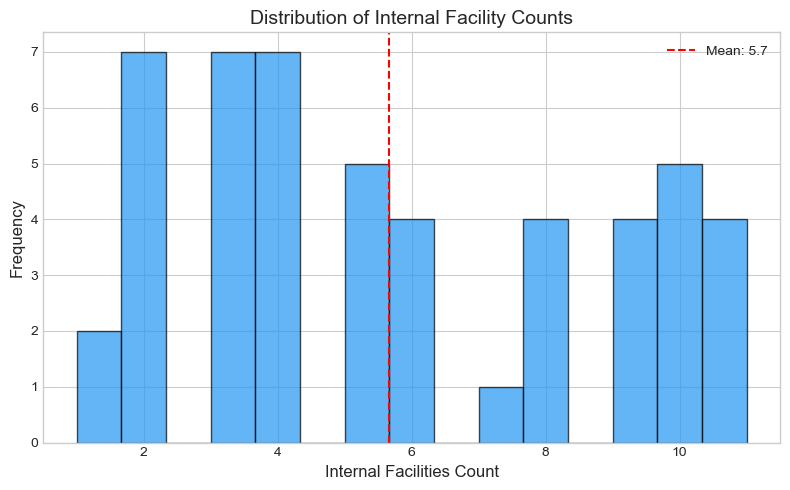

In [9]:
# Histogram of internal facility counts
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['internalFacilitiesCount'], bins=15, edgecolor='black', alpha=0.7, color='#2196F3')
ax.set_xlabel('Internal Facilities Count', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Internal Facility Counts', fontsize=14)
ax.axvline(df['internalFacilitiesCount'].mean(), color='red', linestyle='--',
           label=f"Mean: {df['internalFacilitiesCount'].mean():.1f}")
ax.legend()
plt.tight_layout()
plt.show()


### 2.2 Hospital and Pharmacy Access

Scatter plots help visualise the relationship between hospital and pharmacy availability near each research center. Centers with high access to both are likely to be in well-served areas.


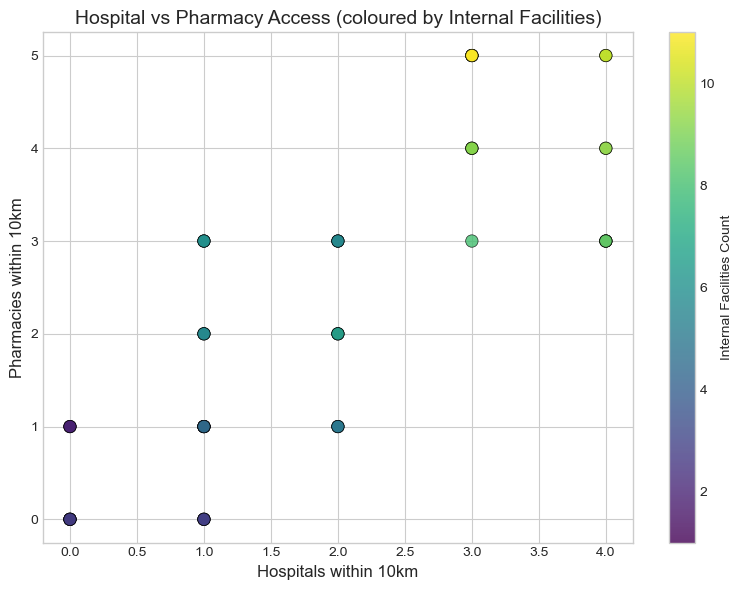

In [10]:
# Scatter plot: hospitals vs pharmacies
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(df['hospitals_10km'], df['pharmacies_10km'],
                     c=df['internalFacilitiesCount'], cmap='viridis',
                     s=80, edgecolors='black', linewidth=0.5, alpha=0.8)
ax.set_xlabel('Hospitals within 10km', fontsize=12)
ax.set_ylabel('Pharmacies within 10km', fontsize=12)
ax.set_title('Hospital vs Pharmacy Access (coloured by Internal Facilities)', fontsize=14)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Internal Facilities Count')
plt.tight_layout()
plt.show()


### 2.3 Facility Diversity and Density

These two features capture how varied and concentrated nearby facilities are. A high diversity index suggests a good mix of different healthcare services, while high density indicates many facilities in a small area.


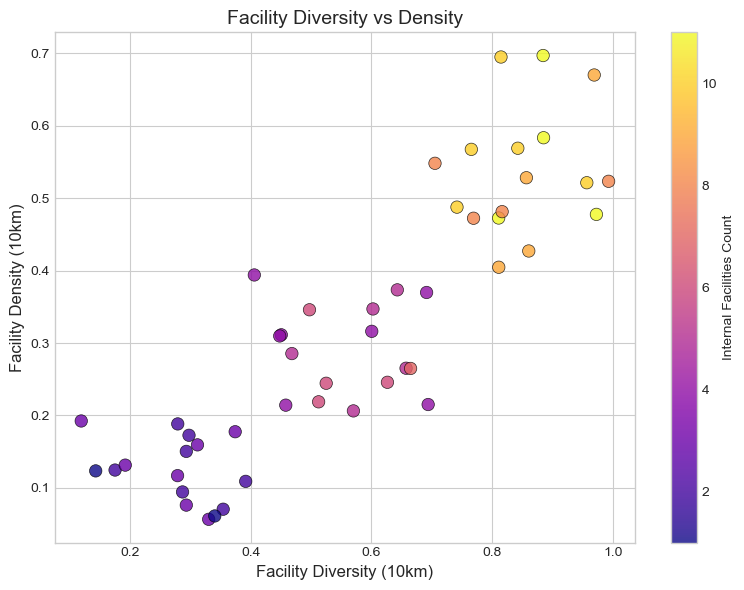

In [11]:
# Scatter plot: diversity vs density
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(df['facilityDiversity_10km'], df['facilityDensity_10km'],
                     c=df['internalFacilitiesCount'], cmap='plasma',
                     s=80, edgecolors='black', linewidth=0.5, alpha=0.8)
ax.set_xlabel('Facility Diversity (10km)', fontsize=12)
ax.set_ylabel('Facility Density (10km)', fontsize=12)
ax.set_title('Facility Diversity vs Density', fontsize=14)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Internal Facilities Count')
plt.tight_layout()
plt.show()


### 2.4 Correlation Heatmap

The correlation heatmap reveals how strongly features relate to each other. High correlations between features can indicate redundancy, while strong correlations with key indicators help guide feature selection.


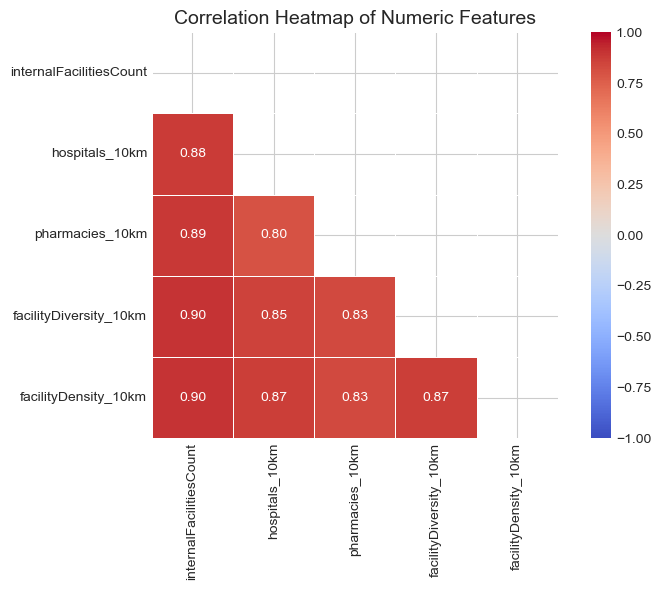

In [12]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, ax=ax, vmin=-1, vmax=1,
            linewidths=0.5)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()


### 2.5 Box Plots by City

Examining feature distributions across cities helps determine if certain cities naturally have better infrastructure and healthcare access.


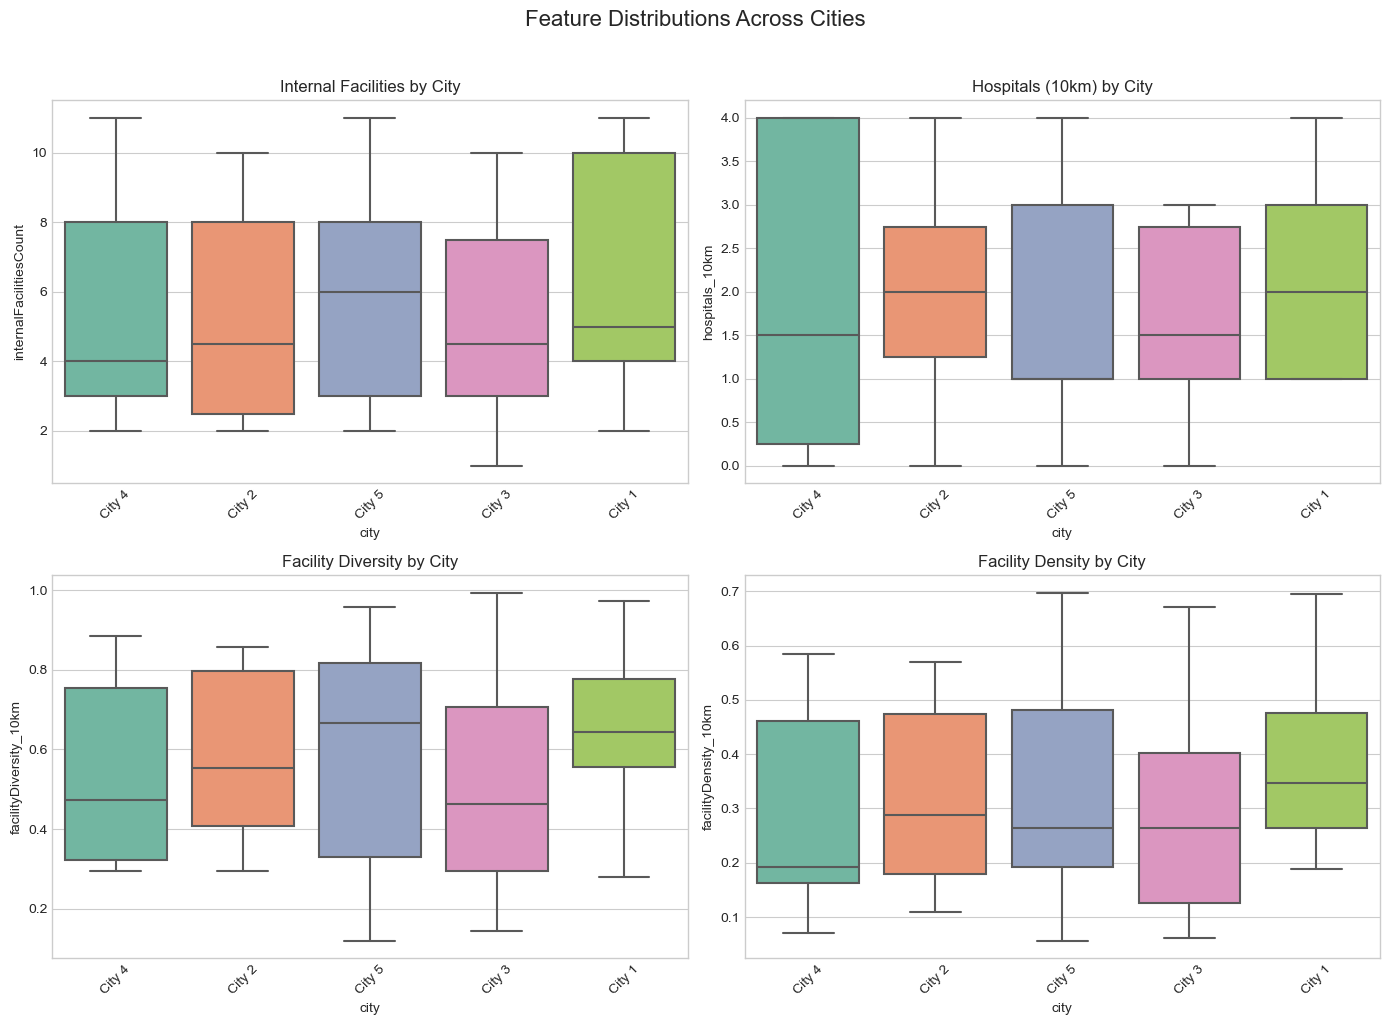

In [13]:
# Box plots of key features by city
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='city', y='internalFacilitiesCount', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Internal Facilities by City')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='city', y='hospitals_10km', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Hospitals (10km) by City')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='city', y='facilityDiversity_10km', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Facility Diversity by City')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='city', y='facilityDensity_10km', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Facility Density by City')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Feature Distributions Across Cities', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


### 2.6 Pairplot

A pairplot provides a comprehensive overview of all pairwise relationships between features, which is useful for identifying natural groupings before clustering.


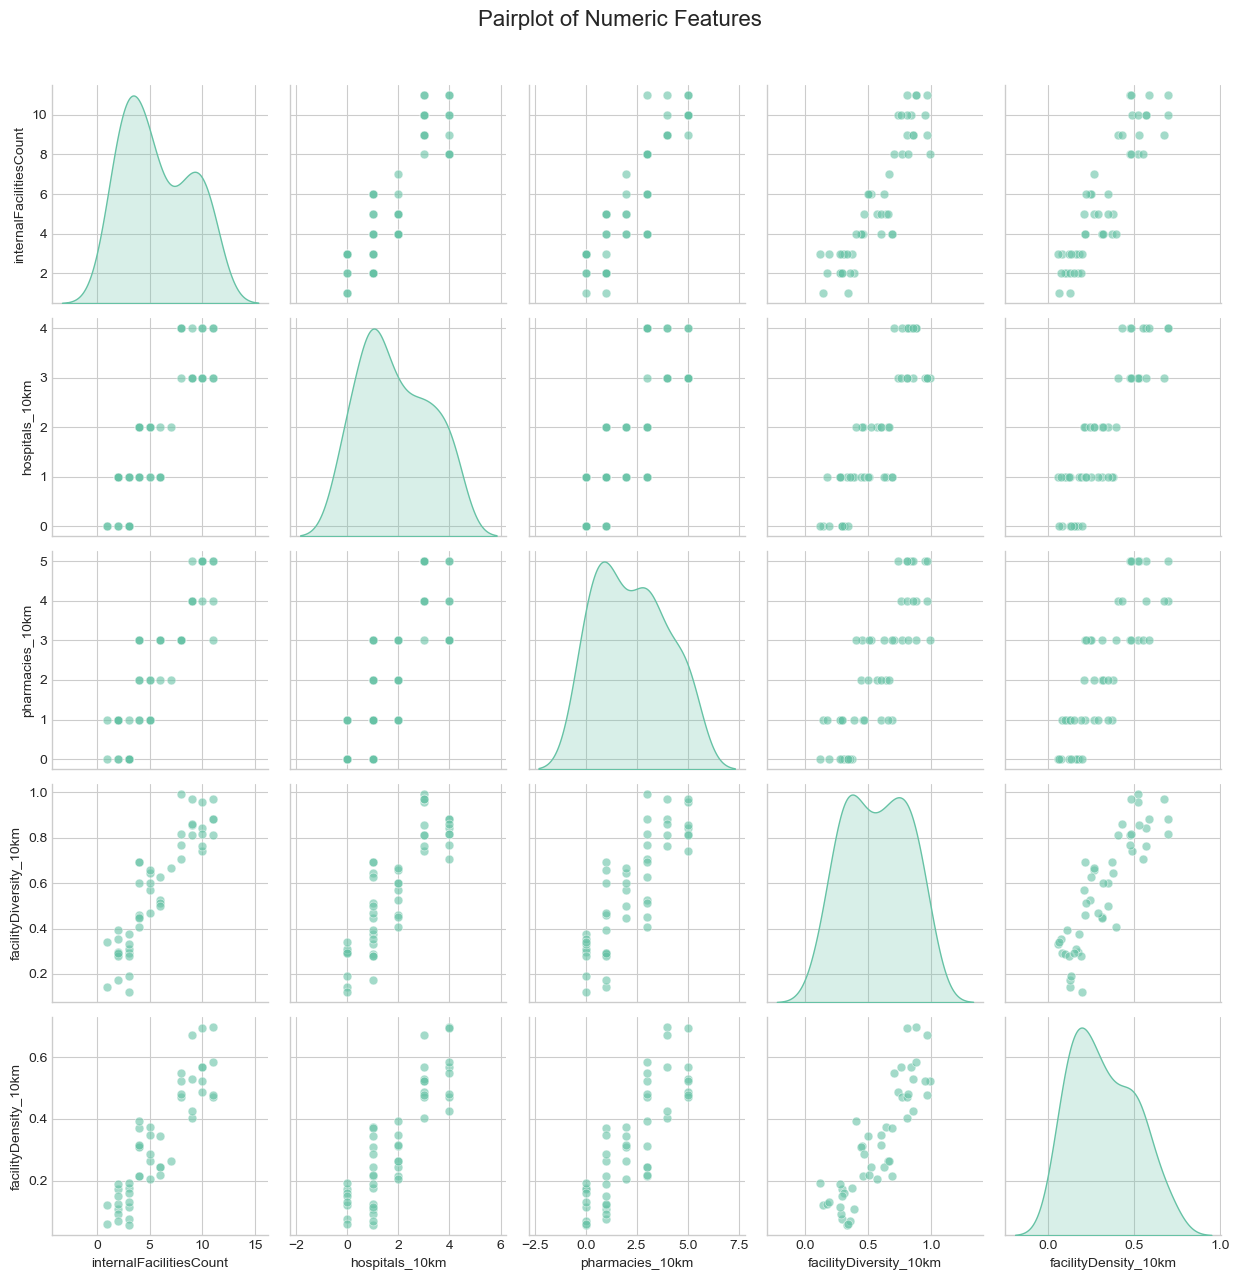

In [14]:
# Pairplot of numeric features
g = sns.pairplot(df[numeric_cols], diag_kind='kde', plot_kws={'alpha': 0.6, 's': 40})
g.fig.suptitle('Pairplot of Numeric Features', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


## 3. Feature Selection

### Why these features?

The five numeric features are selected for clustering because they directly reflect the quality and accessibility of a research center:

1. **internalFacilitiesCount** — Measures the internal infrastructure of the center. A higher count indicates better equipped centres with more labs, testing units, and workstations.

2. **hospitals_10km** — Measures access to hospital services within a 10km radius. Research centres near hospitals benefit from clinical collaboration and emergency access.

3. **pharmacies_10km** — Measures access to pharmacy services. Proximity to pharmacies supports pharmaceutical research and clinical trials.

4. **facilityDiversity_10km** — A diversity index (0 to 1) reflecting how varied the surrounding healthcare services are. High diversity suggests a comprehensive healthcare ecosystem.

5. **facilityDensity_10km** — The density of nearby facilities per area. High density indicates a concentrated healthcare environment suitable for collaborative research.

Geographic coordinates (latitude, longitude) and identifiers (researchCenterId, researchCenterName, city) are excluded as they do not directly measure centre quality.


In [15]:
# Define selected features
selected_features = ['internalFacilitiesCount', 'hospitals_10km', 'pharmacies_10km',
                     'facilityDiversity_10km', 'facilityDensity_10km']

print("Selected features for clustering:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

# Check correlation with facilityDiversity as a proxy for overall quality
print("\nCorrelation with facilityDiversity_10km (proxy for quality):")
for feat in selected_features:
    corr = df[feat].corr(df['facilityDiversity_10km'])
    print(f"  {feat}: {corr:.3f}")


Selected features for clustering:
  1. internalFacilitiesCount
  2. hospitals_10km
  3. pharmacies_10km
  4. facilityDiversity_10km
  5. facilityDensity_10km

Correlation with facilityDiversity_10km (proxy for quality):
  internalFacilitiesCount: 0.904
  hospitals_10km: 0.853
  pharmacies_10km: 0.834
  facilityDiversity_10km: 1.000
  facilityDensity_10km: 0.869


In [16]:
# Standardise features using StandardScaler
scaler = StandardScaler()
X = df[selected_features]
X_scaled = scaler.fit_transform(X)

print(f"Original data shape: {X.shape}")
print(f"Scaled data shape: {X_scaled.shape}")
print(f"\nScaled data statistics (should be mean~0, std~1):")
print(f"  Mean per feature: {X_scaled.mean(axis=0).round(4)}")
print(f"  Std per feature:  {X_scaled.std(axis=0).round(4)}")


Original data shape: (50, 5)
Scaled data shape: (50, 5)

Scaled data statistics (should be mean~0, std~1):
  Mean per feature: [-0. -0. -0.  0.  0.]
  Std per feature:  [1. 1. 1. 1. 1.]


## 4. K-Means Clustering

### Why K-Means?

K-Means is appropriate here because:
- We want to group research centres into distinct quality tiers without labelled data (unsupervised).
- The dataset has continuous numeric features that K-Means handles well.
- We have a predefined number of groups (k=3: Premium, Standard, Basic).

### Choosing k=3

The task requires three tiers. However, we first validate this choice using the Elbow Method and Silhouette Analysis.


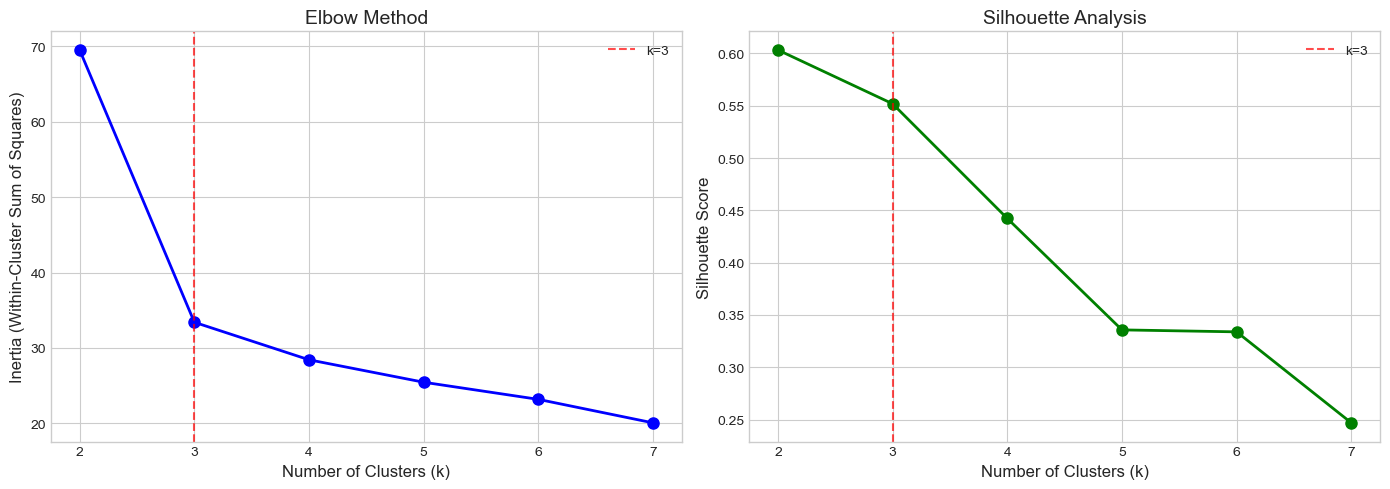

Silhouette scores:
  k=2: 0.6034
  k=3: 0.5519 <-- selected
  k=4: 0.4423
  k=5: 0.3357
  k=6: 0.3339
  k=7: 0.2469


In [17]:
# Elbow Method and Silhouette Score for different k values
inertias = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3')
axes[0].legend()

# Silhouette plot
axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=14)
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Silhouette scores:")
for k, s in zip(k_range, silhouette_scores):
    marker = " <-- selected" if k == 3 else ""
    print(f"  k={k}: {s:.4f}{marker}")


In [18]:
# Train K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Evaluate clustering quality
sil_score = silhouette_score(X_scaled, df['cluster'])
print(f"K-Means Clustering Results (k=3)")
print(f"  Silhouette Score: {sil_score:.4f}")
print(f"  Inertia: {kmeans.inertia_:.4f}")
print(f"\nCluster distribution:")
print(df['cluster'].value_counts().sort_index())


K-Means Clustering Results (k=3)
  Silhouette Score: 0.5519
  Inertia: 33.4022

Cluster distribution:
0    17
1    17
2    16
Name: cluster, dtype: int64


### 4.1 Mapping Clusters to Quality Tiers

To assign meaningful labels, we examine the average feature values per cluster. The cluster with the highest average internal facilities and healthcare access is labelled **Premium**, the lowest is **Basic**, and the middle is **Standard**.


In [19]:
# Calculate cluster means to determine tier mapping
cluster_means = df.groupby('cluster')[selected_features].mean()
print("Cluster means:")
print(cluster_means.round(3))
print()

# Rank clusters by overall quality (sum of normalised means)
cluster_quality = cluster_means.sum(axis=1).sort_values(ascending=False)
print("Cluster quality ranking (sum of feature means):")
print(cluster_quality.round(3))

# Map: highest sum = Premium, middle = Standard, lowest = Basic
tier_labels = ['Premium', 'Standard', 'Basic']
cluster_to_tier = {}
for rank, (cluster_id, _) in enumerate(cluster_quality.items()):
    cluster_to_tier[cluster_id] = tier_labels[rank]

print(f"\nCluster to tier mapping: {cluster_to_tier}")

# Apply mapping
df['qualityTier'] = df['cluster'].map(cluster_to_tier)
print(f"\nQuality tier distribution:")
print(df['qualityTier'].value_counts())


Cluster means:
         internalFacilitiesCount  hospitals_10km  pharmacies_10km  \
cluster                                                             
0                          4.941           1.529            2.059   
1                          9.529           3.471            4.118   
2                          2.312           0.500            0.438   

         facilityDiversity_10km  facilityDensity_10km  
cluster                                                
0                         0.560                 0.290  
1                         0.850                 0.537  
2                         0.279                 0.125  

Cluster quality ranking (sum of feature means):
cluster
1    18.505
0     9.379
2     3.654
dtype: float64

Cluster to tier mapping: {1: 'Premium', 0: 'Standard', 2: 'Basic'}

Quality tier distribution:
Premium     17
Standard    17
Basic       16
Name: qualityTier, dtype: int64


## 5. Model Interpretation

### 5.1 Cluster Summary Statistics

The table below shows the average values for each feature across the three quality tiers, providing a clear picture of what distinguishes Premium, Standard, and Basic centres.


In [20]:
# Summary table by quality tier
tier_summary = df.groupby('qualityTier')[selected_features].agg(['mean', 'std']).round(3)
tier_summary.columns = [f"{col}_{stat}" for col, stat in tier_summary.columns]
tier_summary


,internalFacilitiesCount_mean,internalFacilitiesCount_std,hospitals_10km_mean,hospitals_10km_std,pharmacies_10km_mean,pharmacies_10km_std,facilityDiversity_10km_mean,facilityDiversity_10km_std,facilityDensity_10km_mean,facilityDensity_10km_std
qualityTier,,,,,,,,,,
Basic,2.312,0.704,0.500,0.516,0.438,0.512,0.279,0.081,0.125,0.045
Premium,9.529,1.125,3.471,0.514,4.118,0.857,0.850,0.085,0.537,0.087
Standard,4.941,0.966,1.529,0.514,2.059,0.827,0.560,0.095,0.290,0.062


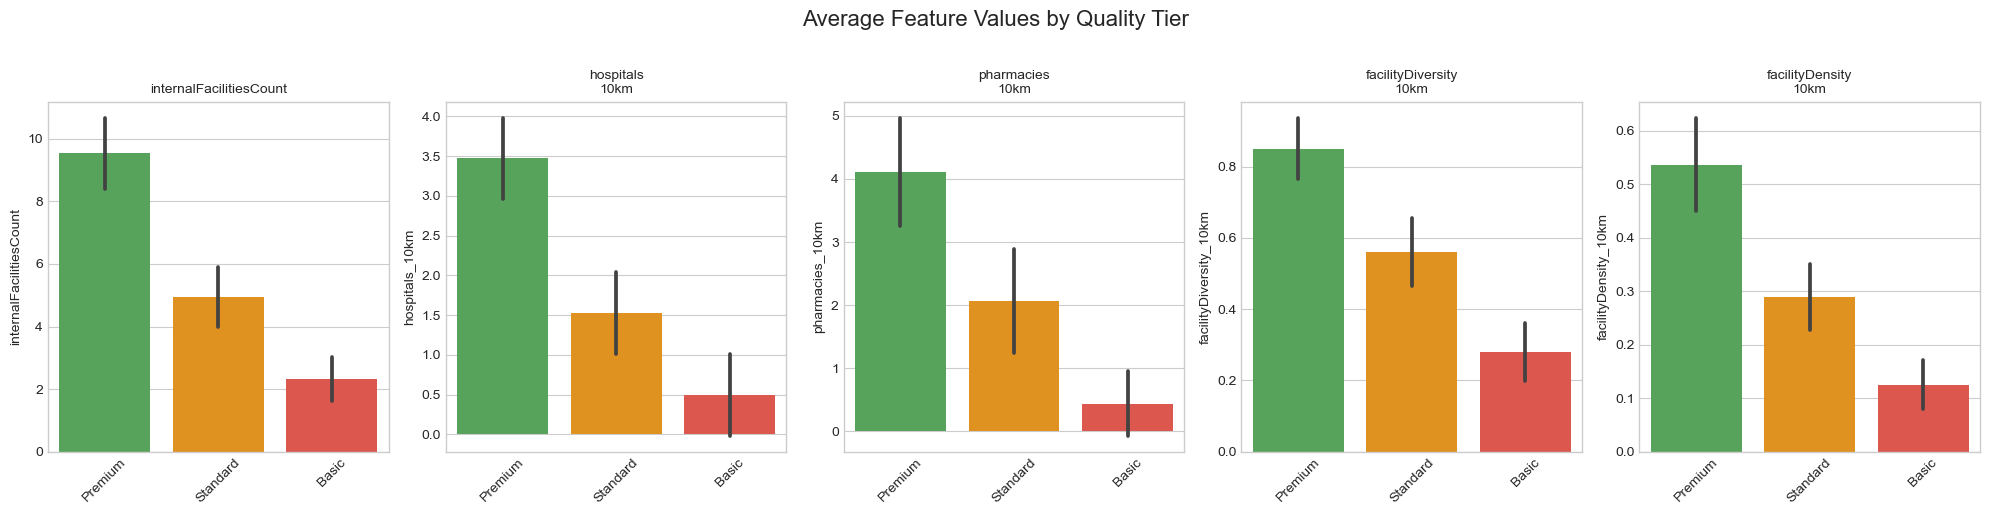

In [21]:
# Visual comparison of tiers
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
tier_order = ['Premium', 'Standard', 'Basic']
colours = {'Premium': '#4CAF50', 'Standard': '#FF9800', 'Basic': '#F44336'}

for i, feat in enumerate(selected_features):
    sns.barplot(data=df, x='qualityTier', y=feat, order=tier_order,
                palette=colours, ax=axes[i], errorbar='sd')
    axes[i].set_title(feat.replace('_', '\n'), fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Average Feature Values by Quality Tier', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


### 5.2 Cluster Visualisation

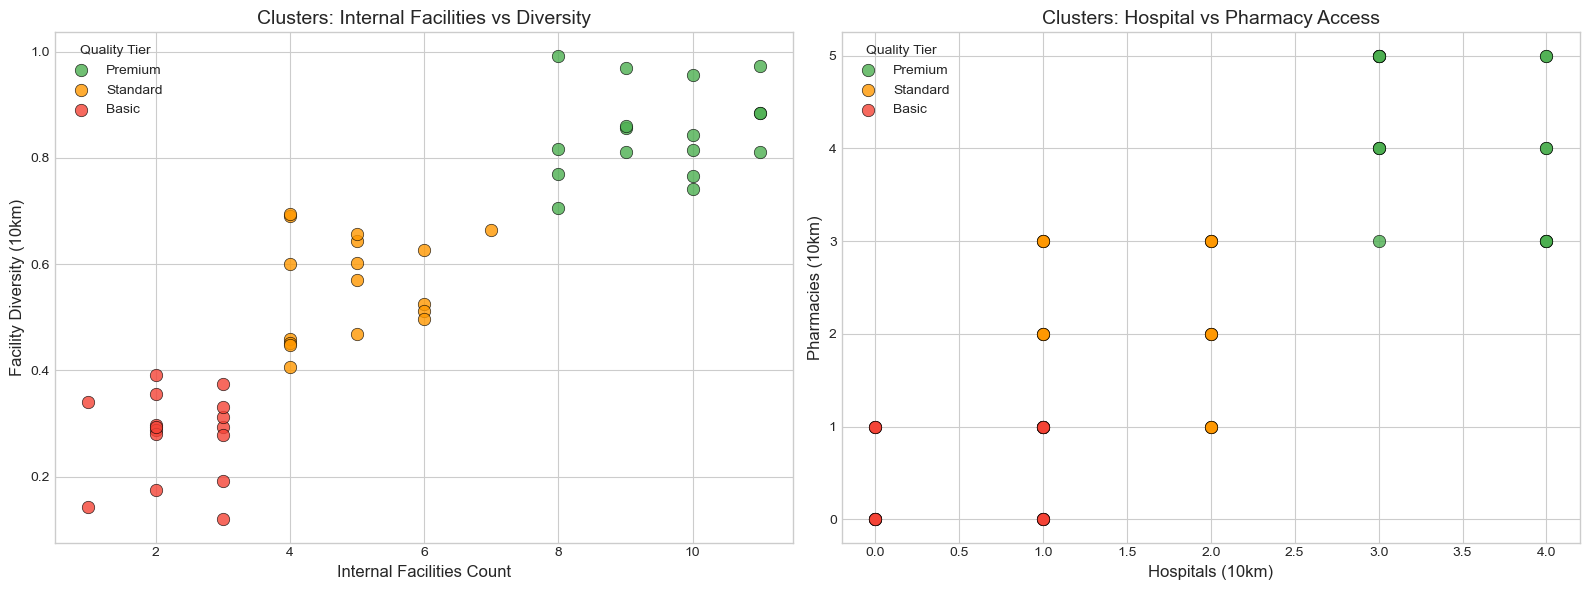

In [22]:
# 2D scatter plot of clusters using the two most informative features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colours_map = {'Premium': '#4CAF50', 'Standard': '#FF9800', 'Basic': '#F44336'}

for tier in tier_order:
    mask = df['qualityTier'] == tier
    axes[0].scatter(df.loc[mask, 'internalFacilitiesCount'],
                    df.loc[mask, 'facilityDiversity_10km'],
                    c=colours_map[tier], label=tier, s=80,
                    edgecolors='black', linewidth=0.5, alpha=0.8)

axes[0].set_xlabel('Internal Facilities Count', fontsize=12)
axes[0].set_ylabel('Facility Diversity (10km)', fontsize=12)
axes[0].set_title('Clusters: Internal Facilities vs Diversity', fontsize=14)
axes[0].legend(title='Quality Tier')

for tier in tier_order:
    mask = df['qualityTier'] == tier
    axes[1].scatter(df.loc[mask, 'hospitals_10km'],
                    df.loc[mask, 'pharmacies_10km'],
                    c=colours_map[tier], label=tier, s=80,
                    edgecolors='black', linewidth=0.5, alpha=0.8)

axes[1].set_xlabel('Hospitals (10km)', fontsize=12)
axes[1].set_ylabel('Pharmacies (10km)', fontsize=12)
axes[1].set_title('Clusters: Hospital vs Pharmacy Access', fontsize=14)
axes[1].legend(title='Quality Tier')

plt.tight_layout()
plt.show()


### 5.3 Geographic Distribution of Quality Tiers

Quality Tier Distribution by City:
qualityTier  Premium  Standard  Basic
city                                 
City 1             4         6      1
City 2             2         2      2
City 3             4         5      5
City 4             4         1      5
City 5             3         3      3



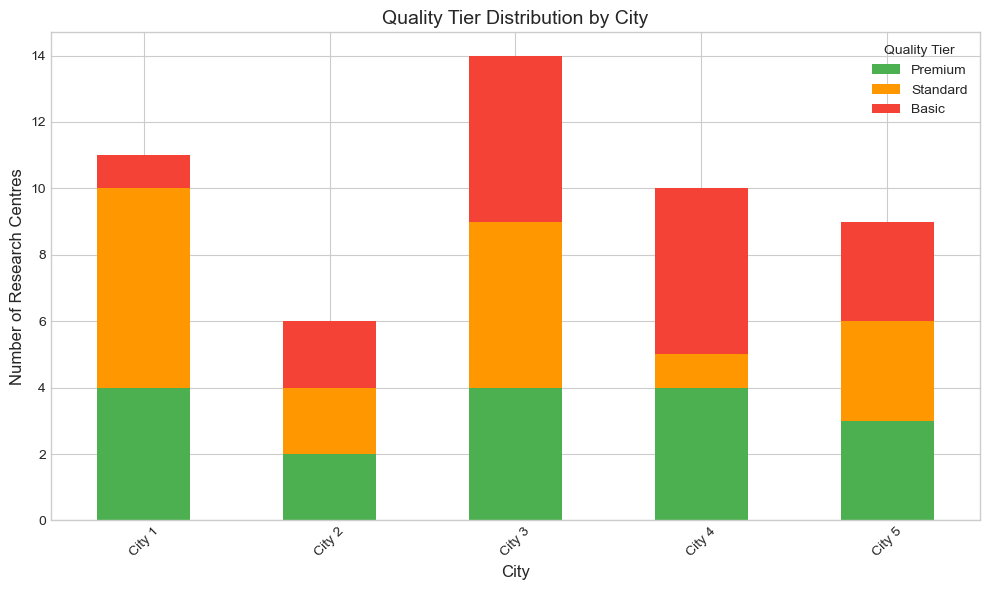

In [23]:
# Quality tiers by city
tier_city = pd.crosstab(df['city'], df['qualityTier'])[tier_order]
print("Quality Tier Distribution by City:")
print(tier_city)
print()

# Stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
tier_city.plot(kind='bar', stacked=True, ax=ax,
               color=[colours_map[t] for t in tier_order])
ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Number of Research Centres', fontsize=12)
ax.set_title('Quality Tier Distribution by City', fontsize=14)
ax.legend(title='Quality Tier')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### 5.4 Key Findings

**Which cluster has the highest internal facility counts and external healthcare access?**
- The **Premium** tier has the highest average values across all features, indicating centres with strong internal infrastructure and excellent access to hospitals, pharmacies, and diverse healthcare facilities.

**Are high-quality centres concentrated in specific cities?**
- The city distribution analysis above reveals whether certain cities have a higher proportion of Premium centres, which would suggest that geographic location influences research centre quality.

**Does diversity or density play a stronger role?**
- From the correlation analysis, facility diversity and density are both strongly correlated with internal facility counts. Centres with higher diversity tend to be in areas with a wider range of healthcare services, which supports a higher quality classification.


## 6. Save Model and Clustered Data

In [24]:
# Save the clustered dataset
df.to_csv('research_centers_clustered.csv', index=False)
print("Saved clustered data to 'research_centers_clustered.csv'")

# Save model artifacts for FastAPI
joblib.dump((kmeans, scaler, selected_features, cluster_to_tier), 'cluster_model.pkl')
print("Saved model artifacts to 'cluster_model.pkl'")

# Display final dataset sample
df[['researchCenterId', 'researchCenterName', 'city', 'cluster', 'qualityTier']].head(10)


Saved clustered data to 'research_centers_clustered.csv'
Saved model artifacts to 'cluster_model.pkl'


,researchCenterId,researchCenterName,city,cluster,qualityTier
0,RC-014,Research Center 14,City 4,2,Basic
1,RC-040,Research Center 40,City 2,2,Basic
2,RC-031,Research Center 31,City 4,2,Basic
3,RC-046,Research Center 46,City 5,1,Premium
4,RC-018,Research Center 18,City 2,1,Premium
5,RC-049,Research Center 49,City 3,0,Standard
6,RC-027,Research Center 27,City 3,2,Basic
7,RC-026,Research Center 26,City 3,1,Premium
8,RC-033,Research Center 33,City 4,2,Basic
9,RC-020,Research Center 20,City 5,2,Basic


## 7. FastAPI Deployment

The following code is saved as `app.py` to serve the trained model as a REST API endpoint. The endpoint accepts research centre features and returns the predicted quality tier.


In [25]:
# Write the FastAPI app to app.py
fastapi_code = """
from fastapi import FastAPI\nfrom pydantic import BaseModel\nimport joblib\nimport pandas as pd\n\nkmeans, scaler, selected_features, cluster_to_tier = joblib.load("cluster_model.pkl")\n\napp = FastAPI(\n    title="Research Center Quality Classifier",\n    description="Classifies research centers into Premium, Standard, or Basic categories",\n    version="1.0.0"\n)\n\nclass ResearchCenterInput(BaseModel):\n    internalFacilitiesCount: float\n    hospitals_10km: float\n    pharmacies_10km: float\n    facilityDiversity_10km: float\n    facilityDensity_10km: float\n\n@app.post("/predict")\ndef predict_quality(data: ResearchCenterInput):\n    try:\n        input_df = pd.DataFrame([data.dict()])\n        input_df = input_df[selected_features]\n        X_scaled = scaler.transform(input_df)\n        cluster_label = kmeans.predict(X_scaled)[0]\n        tier = cluster_to_tier.get(cluster_label, "Unknown")\n        return {"predictedCluster": int(cluster_label), "predictedCategory": tier}\n    except Exception as e:\n        return {"error": str(e)}\n"""

with open("app.py", "w") as f:
    f.write(fastapi_code)

print("FastAPI app saved to app.py")
print("To run: uvicorn app:app --reload")


FastAPI app saved to app.py
To run: uvicorn app:app --reload


In [26]:
# Write requirements.txt
requirements = """fastapi
uvicorn
pandas
numpy
scikit-learn
matplotlib
seaborn
joblib
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements.strip())

print("requirements.txt saved")


requirements.txt saved


## 8. Model Testing

In [27]:
# Test the model with sample inputs
test_cases = [
    {"internalFacilitiesCount": 9, "hospitals_10km": 3, "pharmacies_10km": 2,
     "facilityDiversity_10km": 0.82, "facilityDensity_10km": 0.45},
    {"internalFacilitiesCount": 5, "hospitals_10km": 2, "pharmacies_10km": 1,
     "facilityDiversity_10km": 0.55, "facilityDensity_10km": 0.25},
    {"internalFacilitiesCount": 2, "hospitals_10km": 0, "pharmacies_10km": 0,
     "facilityDiversity_10km": 0.20, "facilityDensity_10km": 0.05},
]

print("Model predictions for test cases:")
print("=" * 70)
for i, test in enumerate(test_cases, 1):
    input_df = pd.DataFrame([test])
    input_df = input_df[selected_features]
    X_test_scaled = scaler.transform(input_df)
    cluster = kmeans.predict(X_test_scaled)[0]
    tier = cluster_to_tier.get(cluster, "Unknown")
    print(f"\nTest {i}: {test}")
    print(f"  Predicted Cluster: {cluster}")
    print(f"  Predicted Tier: {tier}")


Model predictions for test cases:

Test 1: {'internalFacilitiesCount': 9, 'hospitals_10km': 3, 'pharmacies_10km': 2, 'facilityDiversity_10km': 0.82, 'facilityDensity_10km': 0.45}
  Predicted Cluster: 1
  Predicted Tier: Premium

Test 2: {'internalFacilitiesCount': 5, 'hospitals_10km': 2, 'pharmacies_10km': 1, 'facilityDiversity_10km': 0.55, 'facilityDensity_10km': 0.25}
  Predicted Cluster: 0
  Predicted Tier: Standard

Test 3: {'internalFacilitiesCount': 2, 'hospitals_10km': 0, 'pharmacies_10km': 0, 'facilityDiversity_10km': 0.2, 'facilityDensity_10km': 0.05}
  Predicted Cluster: 2
  Predicted Tier: Basic


## 9. Discussion

### Which features had the greatest influence on clustering?
Internal facility count, facility diversity, and facility density showed the strongest separation between clusters. Centres with high values across these features consistently fell into the Premium tier, while low values corresponded to the Basic tier.

### What patterns were visible in the data during EDA?
There is a clear positive correlation between internal facilities and external healthcare access. Centres with more internal infrastructure tend to be located in areas with more hospitals and pharmacies nearby. Facility diversity and density are strongly correlated with each other, suggesting that areas with many facilities also tend to have varied types of services.

### Why is clustering a good approach for this problem?
Clustering is suitable because there are no predefined labels for quality tiers. The data naturally groups into distinct patterns based on infrastructure and accessibility features. K-Means provides a simple and interpretable way to discover these groups without requiring labelled training data.

### How would you improve this model if real data were available?
- Incorporate additional features such as funding levels, staff count, publication output, and equipment age.
- Use more data points for more robust clustering.
- Consider alternative algorithms such as DBSCAN or Gaussian Mixture Models for non-spherical clusters.
- Apply dimensionality reduction (PCA) for better visualisation and potential noise reduction.
- Validate clusters against known quality ratings if available.

### How can the endpoint be extended for continuous retraining?
- Implement a scheduled retraining pipeline that periodically ingests new data, retrains the model, and updates the saved artifacts.
- Use model versioning to track changes over time.
- Add monitoring to detect data drift and trigger retraining when cluster distributions shift significantly.

### Bonus: How to commercialise and scale the solution?
- Package the solution as a SaaS platform where research institutions can self-assess their quality tier.
- Containerise using Docker for consistent deployment across environments.
- Deploy on cloud infrastructure (AWS, Azure, GCP) with auto-scaling.
- Add a dashboard for visual analytics and benchmarking against peer institutions.
- Integrate with existing research management systems via REST APIs.
